# BV2 Übungsblatt 05: CNN auf GTSRB

## Aufgabenstellung
Trainieren Sie ein eigenes CNN auf den GTSRB-Trainingsdaten (German Traffic Sign Recognition Benchmark). 
Ziel ist es, eine möglichst gute Generalisierungsfähigkeit zu erreichen (> 98.84% ist das Ziel für übermenschliche Leistung).

Datenquelle: https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html oder via Torchvision.


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device config
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Patch for MacOS/Python network issues (Force IPv4) ---
import socket
def forced_ipv4(host, port, family=socket.AF_INET, type=socket.SOCK_STREAM, proto=0, flags=0):
    # Force AF_INET (IPv4)
    return socket._original_getaddrinfo(host, port, socket.AF_INET, type, proto, flags)

# Save original getaddrinfo if not saved yet
""" if not hasattr(socket, "_original_getaddrinfo"):
    socket._original_getaddrinfo = socket.getaddrinfo
    socket.getaddrinfo = forced_ipv4
    print("Patched socket.getaddrinfo to force IPv4 to avoid URLError [Errno 49]") """


Using device: mps


' if not hasattr(socket, "_original_getaddrinfo"):\n    socket._original_getaddrinfo = socket.getaddrinfo\n    socket.getaddrinfo = forced_ipv4\n    print("Patched socket.getaddrinfo to force IPv4 to avoid URLError [Errno 49]") '

## 1. Daten laden und vorbereiten

Wir nutzen `torchvision.datasets.GTSRB` falls möglich, oder laden die Daten manuell herunter.
Die Bilder im GTSRB Datensatz haben unterschiedliche Größen, daher müssen wir sie auf eine einheitliche Größe skalieren (z.B. 32x32 oder 48x48).


In [2]:
# Hyperparameters
BATCH_SIZE = 64
IMG_SIZE = (32, 32)  # Common size for traffic signs
NUM_CLASSES = 43

# Transforms with Augmentation for Training
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    #transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    #transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669]) # GTSRB Mean/Std
])

# Transforms for Validation/Test (No augmentation)
test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669])
])

In [3]:
DATA_DIR = "data"

# Download Training Data
try:
    train_dataset_full = datasets.GTSRB(root=DATA_DIR, split="train", download=True, transform=train_transforms)
    test_dataset = datasets.GTSRB(root=DATA_DIR, split="test", download=True, transform=test_transforms)
    print("GTSRB Download successful.")
except RuntimeError as e:
    print(f"Download failed or data already exists: {e}")
    print("If the error persists, please check internet connection or manually download GTSRB.")

print(f"Training set size: {len(train_dataset_full)}")
print(f"Test set size: {len(test_dataset)}")

GTSRB Download successful.
Training set size: 26640
Test set size: 12630


In [4]:
# Split Training into Train and Validation
val_size = int(0.2 * len(train_dataset_full)) # set validation size to 20%
train_size = len(train_dataset_full) - val_size

train_subset, val_subset = random_split(train_dataset_full, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 333
Val batches: 84


## 2. CNN Modell definieren

Wir definieren ein CNN mit Convolutional Layern, Batch Normalization und Dropout, um Overfitting zu vermeiden und die Generalisierung zu verbessern.


In [5]:
class GTSRB_CNN(nn.Module):
    def __init__(self, num_classes=43):
        super(GTSRB_CNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)
        
        # Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout(0.25)
        
        # Fully Connected
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.dropout_fc1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        x = self.flatten(x)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc1(x)
        x = self.fc2(x)
        return x

model = GTSRB_CNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

GTSRB_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), pa

## 3. Training Setup
Optimizer (Adam), Loss Function (CrossEntropy) und LR Scheduler.


In [ ]:
LEARNING_RATE = 0.001
EPOCHS = 30

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    loss = running_loss / total
    acc = correct / total
    return loss, acc

In [7]:
# Training Loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_acc = 0.0

start = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    
    scheduler.step(val_acc)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        model_path = "bv2_a05_GTSRB_model_06.pth"
        torch.save(model.state_dict(), model_path)
        print("  --> Saved new best model")

print(f"Best Validation Accuracy: {best_acc:.4f}")
print(f"\nTraining took {time.time() - start:.2f} seconds")

Epoch 1/30 | Train Loss: 1.8477 Acc: 0.4886 | Val Loss: 0.5643 Acc: 0.8504
  --> Saved new best model
Epoch 2/30 | Train Loss: 0.4693 Acc: 0.8750 | Val Loss: 0.1187 Acc: 0.9752
  --> Saved new best model
Epoch 3/30 | Train Loss: 0.2049 Acc: 0.9487 | Val Loss: 0.0465 Acc: 0.9902
  --> Saved new best model
Epoch 4/30 | Train Loss: 0.1288 Acc: 0.9667 | Val Loss: 0.0294 Acc: 0.9927
  --> Saved new best model
Epoch 5/30 | Train Loss: 0.0887 Acc: 0.9764 | Val Loss: 0.0218 Acc: 0.9944
  --> Saved new best model
Epoch 6/30 | Train Loss: 0.0742 Acc: 0.9794 | Val Loss: 0.0210 Acc: 0.9944
Epoch 7/30 | Train Loss: 0.0626 Acc: 0.9824 | Val Loss: 0.0129 Acc: 0.9968
  --> Saved new best model
Epoch 8/30 | Train Loss: 0.0529 Acc: 0.9851 | Val Loss: 0.0161 Acc: 0.9957
Epoch 9/30 | Train Loss: 0.0453 Acc: 0.9870 | Val Loss: 0.0102 Acc: 0.9964
Epoch 10/30 | Train Loss: 0.0425 Acc: 0.9881 | Val Loss: 0.0083 Acc: 0.9977
  --> Saved new best model
Epoch 11/30 | Train Loss: 0.0353 Acc: 0.9900 | Val Loss: 0.0

## 4. Evaluierung auf Testdaten
Wir laden das beste Modell und testen es auf dem offiziellen Testset.


In [8]:
# Load Best Model
model.load_state_dict(torch.load(model_path))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test Set Accuracy: {test_acc*100:.2f}%")

if test_acc > 0.9884:
    print("SUPERHUMAN PERFORMANCE ACHIEVED! 🚀")
else:
    print("Good job, keep tuning!")

Test Set Accuracy: 98.28%
Good job, keep tuning!


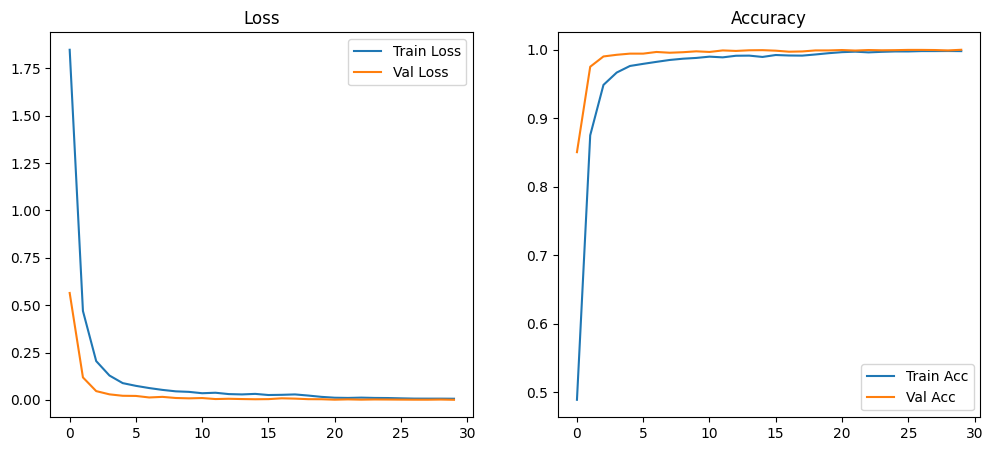

In [9]:
# Plotting Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()